In [10]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp
# Load dataset
df = pd.read_csv("supermarket_sales.csv")

In [11]:
print("First five records:")
print(df.head())

First five records:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1

In [12]:
# In this dataset, Total represents the sales/revenue amount
revenue = df["Total"]
print("Revenue column:")
print(revenue)

Revenue column:
0       548.9715
1        80.2200
2       340.5255
3       489.0480
4       634.3785
         ...    
995      42.3675
996    1022.4900
997      33.4320
998      69.1110
999     649.2990
Name: Total, Length: 1000, dtype: float64


In [13]:
print("Missing values in revenue:")
print(revenue.isnull().sum())

Missing values in revenue:
0


In [14]:
mean_revenue = revenue.mean()
print("Mean Revenue:", mean_revenue)

Mean Revenue: 322.966749


In [15]:
expected_revenue = 1500
print("Expected Average Revenue: ₹", expected_revenue)

Expected Average Revenue: ₹ 1500


In [17]:
# H0: μ = 1500
print("Null Hypothesis (H0): μ = 1500")

Null Hypothesis (H0): μ = 1500


In [18]:
# H1: μ != 1500
print("Alternative Hypothesis (H1): μ != 1500")

Alternative Hypothesis (H1): μ != 1500


In [19]:
alpha = 0.05
print("Significance Level:", alpha)

Significance Level: 0.05


In [20]:
t_statistic, p_value = ttest_1samp(
    revenue,
    expected_revenue
)
print("T-statistic:", t_statistic)

T-statistic: -151.37567896776733


In [21]:
print("P-value:", p_value)

P-value: 0.0


In [22]:
if p_value < alpha:
    print("P-value is less than 0.05")
else:
    print("P-value is greater than or equal to 0.05")

P-value is less than 0.05


In [23]:
if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H0)")
else:
    print("Decision: Do Not Reject the Null Hypothesis (H0)")

Decision: Reject the Null Hypothesis (H0)


In [24]:
if p_value < alpha:
    print("Conclusion:")
    print("The average revenue is significantly different from ₹1,500.")
else:
    print("Conclusion:")
    print("There is not enough evidence to conclude that the average revenue is different from ₹1,500.")

Conclusion:
The average revenue is significantly different from ₹1,500.


part B A/B Testing

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
df = pd.read_csv("ab_testing.csv")

In [27]:
print(df)

  Group  Users  Conversions
0     A   1000          120
1     B   1000          150


In [28]:
group_A = df[df["Group"] == "A"]
users_A = group_A["Users"].iloc[0]
conversions_A = group_A["Conversions"].iloc[0]
conversion_rate_A = conversions_A / users_A
print("Conversion Rate of Group A:", conversion_rate_A)
print("Conversion Rate of Group A:", conversion_rate_A * 100, "%")

Conversion Rate of Group A: 0.12
Conversion Rate of Group A: 12.0 %


In [29]:
group_B = df[df["Group"] == "B"]
users_B = group_B["Users"].iloc[0]
conversions_B = group_B["Conversions"].iloc[0]
conversion_rate_B = conversions_B / users_B
print("Conversion Rate of Group B:", conversion_rate_B)
print("Conversion Rate of Group B:", conversion_rate_B * 100, "%")

Conversion Rate of Group B: 0.15
Conversion Rate of Group B: 15.0 %


In [30]:
print("Conversion Rate of Group A:", conversion_rate_A * 100, "%")
print("Conversion Rate of Group B:", conversion_rate_B * 100, "%")
difference = (conversion_rate_B - conversion_rate_A) * 100
print("Difference:", difference, "percentage points")

Conversion Rate of Group A: 12.0 %
Conversion Rate of Group B: 15.0 %
Difference: 3.0 percentage points


In [31]:
print("H0: pA = pB")

H0: pA = pB


In [32]:
print("H1: pA != pB")

H1: pA != pB


In [33]:
alpha = 0.05
print("Significance Level:", alpha)

Significance Level: 0.05


In [34]:
conversions = np.array([conversions_A, conversions_B])
users = np.array([users_A, users_B])
z_statistic, p_value = proportions_ztest(
    conversions,
    users
)
print("Z-statistic:", z_statistic)

Z-statistic: -1.963049807622355


In [35]:
print("P-value:", p_value)

P-value: 0.04964038686536878


In [36]:
if p_value < 0.05:
    print("P-value is less than 0.05")
else:
    print("P-value is greater than or equal to 0.05")

P-value is less than 0.05


In [37]:
if p_value < 0.05:
    print("Reject the Null Hypothesis (H0)")
else:
    print("Do Not Reject the Null Hypothesis (H0)")

Reject the Null Hypothesis (H0)


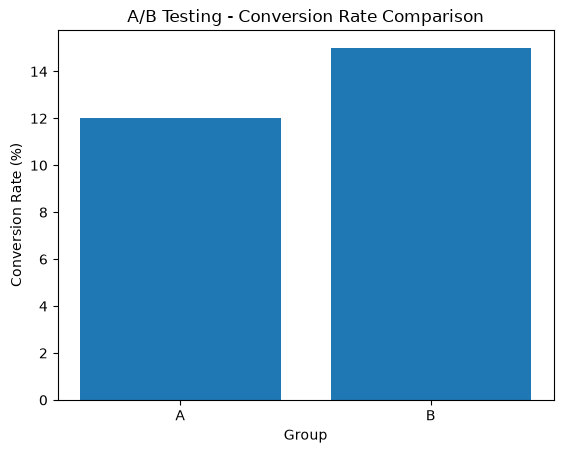

In [38]:
groups = ["A", "B"]
conversion_rates = [
    conversion_rate_A * 100,
    conversion_rate_B * 100
]
plt.bar(groups, conversion_rates)
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.title("A/B Testing - Conversion Rate Comparison")
plt.show()

In [39]:
if p_value < 0.05:
    print("Conclusion:")
    print("There is a statistically significant difference")
    print("between the conversion rates of Group A and Group B.")
else:
    print("Conclusion:")
    print("There is no statistically significant difference")
    print("between the conversion rates of Group A and Group B.")

Conclusion:
There is a statistically significant difference
between the conversion rates of Group A and Group B.
